# Introdução ao Aprendizado de Máquina - EEL891 - 2024.1
## Relatório do Trabalho de Regressão
<b>Aluno: </b>Victor Ribeiro Alves<br>
<b>DRE:</b> 120035521<br>
<b>Professor: </b>Heraldo Luís Silveira de Almeida

## 1 - Análise dos Dados
Com o intuito de entender melhor os dados utilizados, farei uma breve análise exploratória dos dados.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
import numpy as np

In [2]:
data_train = pd.read_csv('data/conjunto_de_treinamento.csv')
data_test = pd.read_csv('data/conjunto_de_teste.csv')

data_train.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


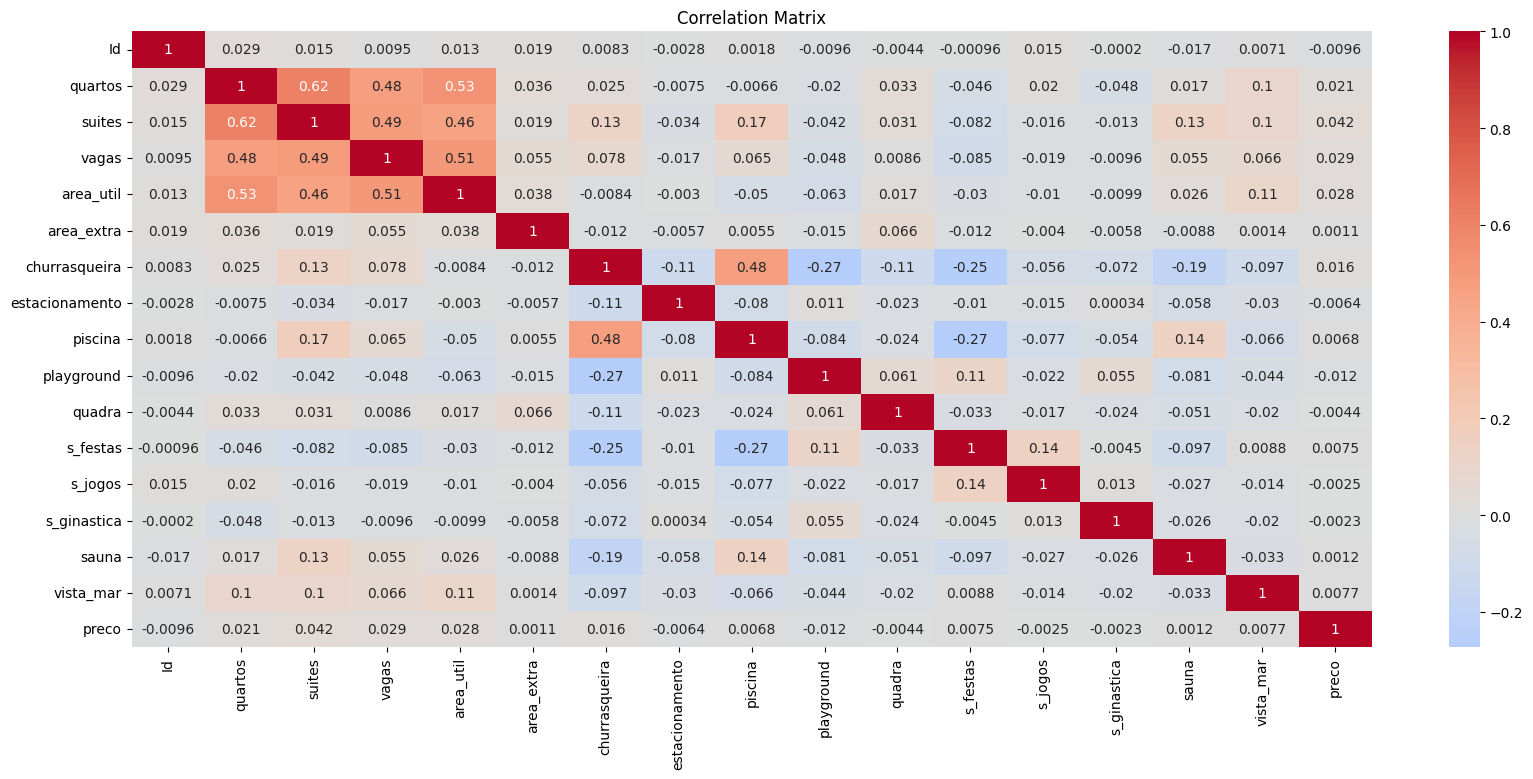

In [3]:
numerical_df = data_train.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Para evitar distorções na escala do gráfico, removi os outliers (3 imóveis com preço superior a R$60.000.000).

Quantidade de imoveis com preço superior a R$60.000.000: 3


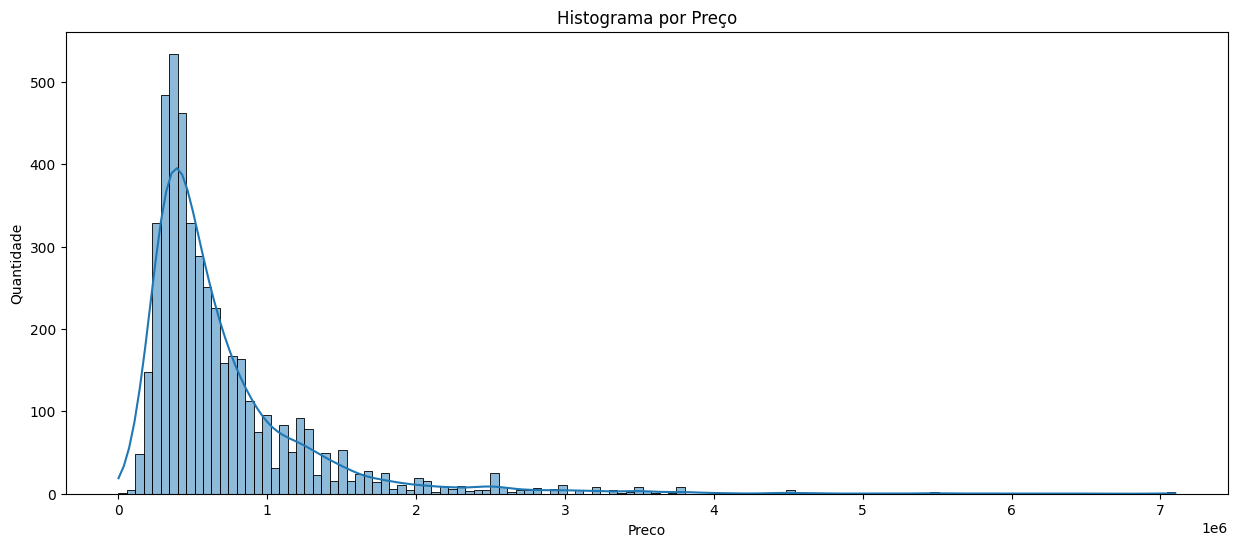

In [4]:
plt.figure(figsize=(15, 6))
data_plot = data_train[data_train['preco'] < 60000000]
print(f'Quantidade de imoveis com preço superior a R$60.000.000: {len((data_train[data_train["preco"]>= 60000000]).index)}')
sns.histplot(x='preco', data=data_plot, kde=True)
plt.title('Histograma por Preço')
plt.xlabel('Preco')
plt.ylabel('Quantidade')
plt.show()

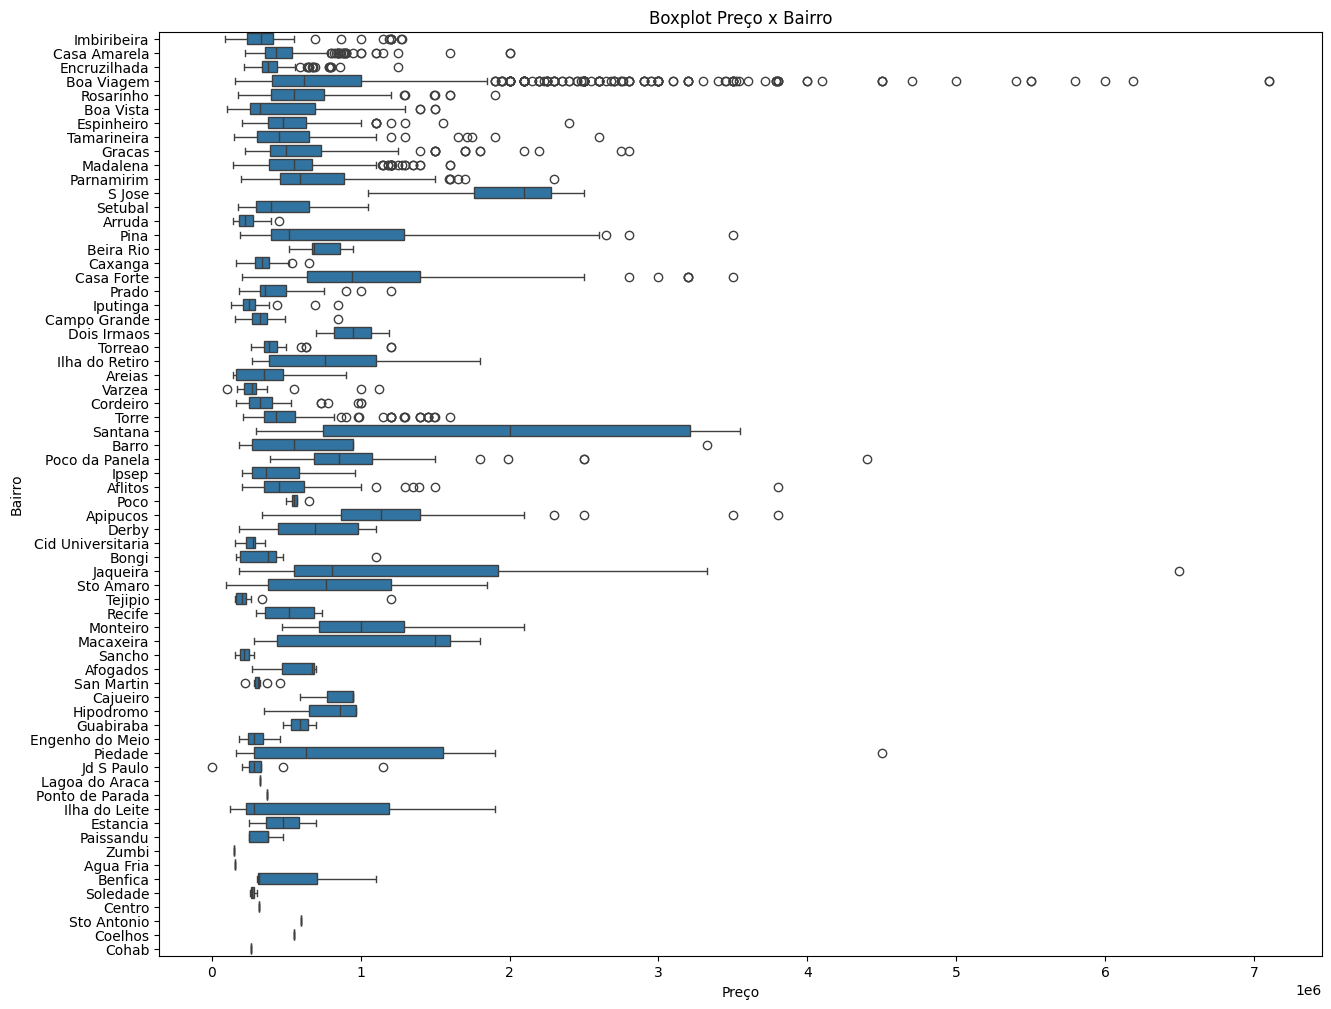

In [5]:
plt.figure(figsize=(15, 12))
sns.boxplot(y='bairro', x='preco', data=data_plot)
plt.title('Boxplot Preço x Bairro')
plt.xlabel('Preço')
plt.ylabel('Bairro')
plt.show()

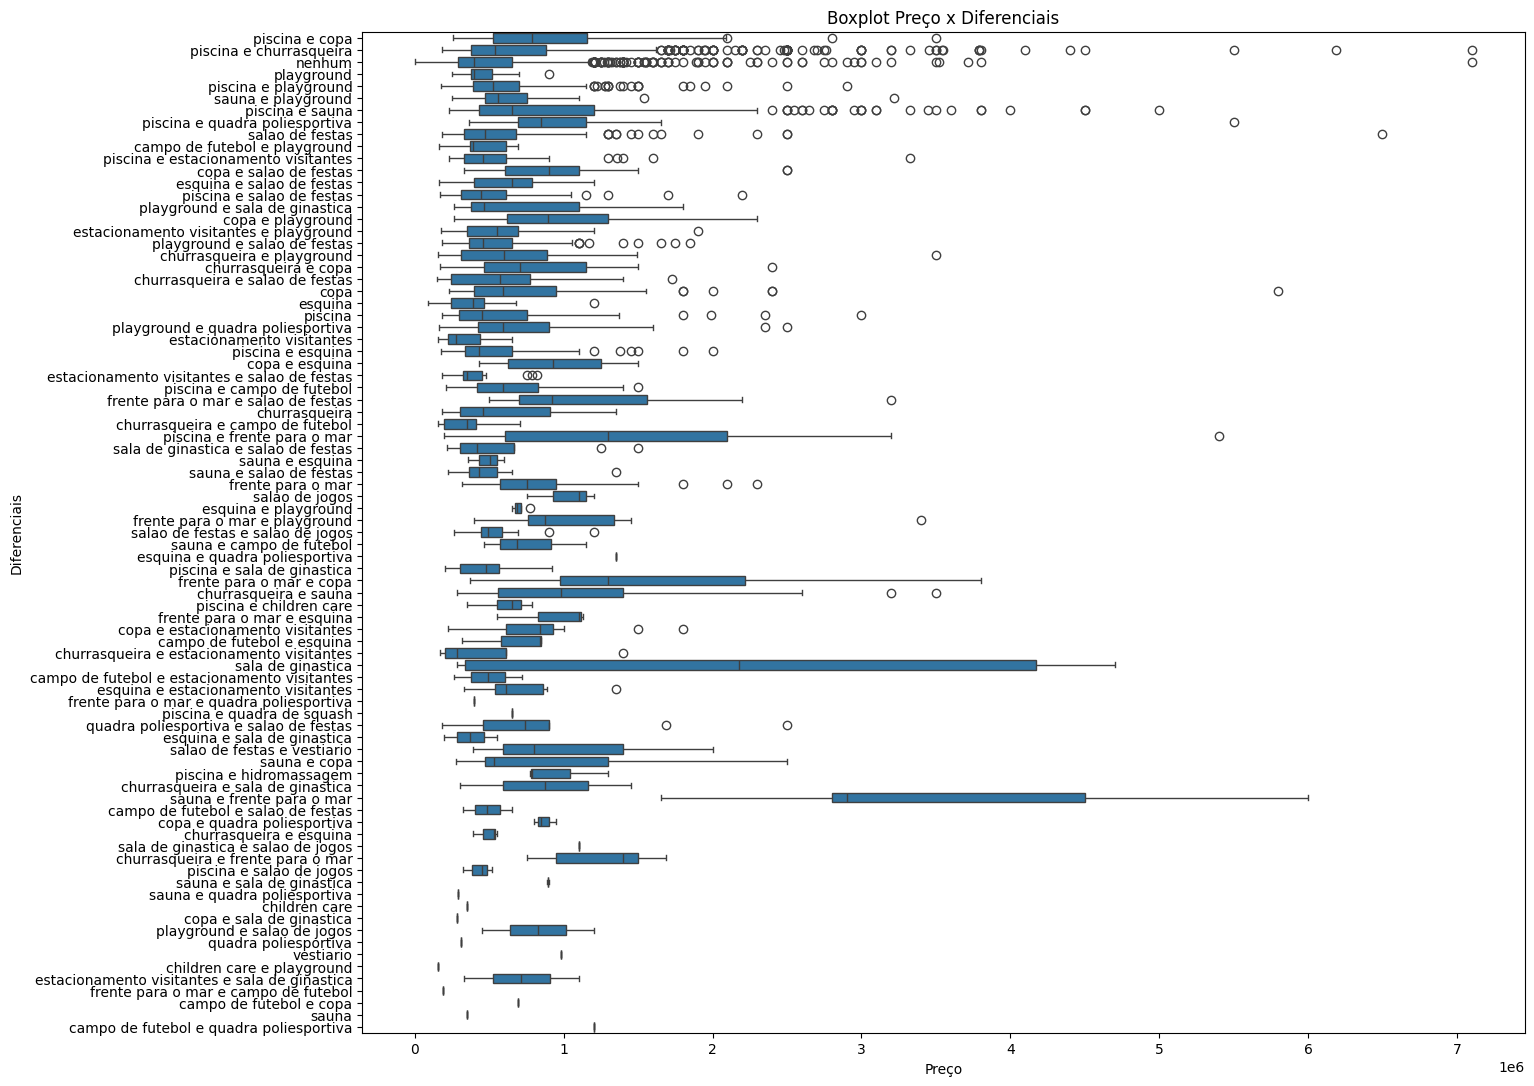

In [6]:
plt.figure(figsize=(15, 13))
sns.boxplot(y='diferenciais', x='preco', data=data_plot)
plt.title('Boxplot Preço x Diferenciais')
plt.xlabel('Preço')
plt.ylabel('Diferenciais')
plt.show()

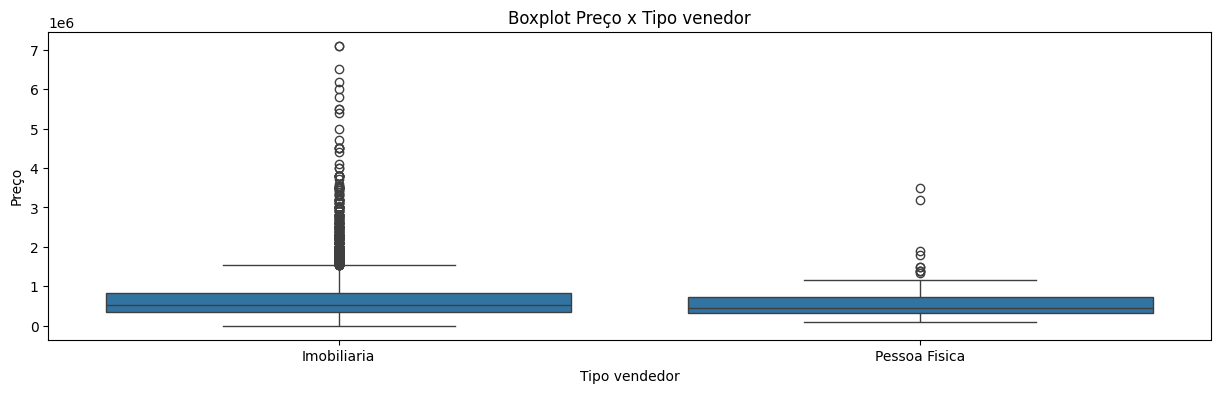

In [7]:
plt.figure(figsize=(15, 4))
sns.boxplot(y='preco', x='tipo_vendedor', data=data_plot)
plt.title('Boxplot Preço x Tipo venedor')
plt.xlabel('Tipo vendedor')
plt.ylabel('Preço')
plt.show()

## 2 - Pré-processamento dos Dados
Para evitar retrabalho, carregarei os dados de treinamento e previsão juntos em um único dataframe e aplicarei as alterações necessárias para pré-processamento dos dados. Depois, dividirei os dados novamente para testar o modelo.

In [8]:
data_test = pd.read_csv('data/conjunto_de_teste.csv')
data_train = pd.read_csv('data/conjunto_de_treinamento.csv')
id_kaggle = data_test['Id'] 
splitting_idx = len(data_train)
display(data_test.head())

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar
0,0,Apartamento,Pina,Imobiliaria,4,4,3,182,0,copa e playground,0,0,0,1,0,0,0,0,0,0
1,1,Apartamento,Tamarineira,Imobiliaria,2,0,1,85,0,nenhum,0,0,0,0,0,0,0,0,0,0
2,2,Apartamento,Boa Viagem,Imobiliaria,3,1,2,115,20,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0
3,3,Apartamento,Iputinga,Imobiliaria,3,0,1,92,0,nenhum,0,0,0,0,0,0,0,0,0,0
4,4,Apartamento,Engenho do Meio,Imobiliaria,3,1,1,65,0,piscina e copa,0,0,1,0,0,0,0,0,0,0


### 2.1 - Removendo Outliers
- Na análise do dataset identifiquei pouquissímos imóveis com valor superior a R$60.000.000. Portanto, estes serão considerados outliers e serão removidos.

In [9]:
count_outliers = len((data_train[data_train["preco"]>= 60000000]).index)
print(f'Quantidade de imoveis com preço superior a R$60.000.000: {count_outliers} -> {(count_outliers/len(data_train.index))*100:.2f}% do dataset')
data_train = data_train[data_train['preco'] < 60000000]
splitting_idx = splitting_idx - count_outliers
data = pd.concat([data_train, data_test], ignore_index=True)

Quantidade de imoveis com preço superior a R$60.000.000: 3 -> 0.06% do dataset


### 2.2 - Buscando por valores nulos

In [10]:
sum_nulls = data.isnull().sum()
column_with_null = sum_nulls[sum_nulls > 0]
column_with_null.drop('preco', inplace=True)
display(column_with_null.sort_index())

Series([], dtype: int64)

- Neste conjunto de dados, não é necessário tratar os valores nulos pois estão preenchidos corretamente.

### 2.3 - Tratando variáveis categóricas
- As variáveis tipo_vendedor e diferenciais não parecem fornecer muitas informações para o modelo. Isto foi comprovado nos testes com os modelos e a pontuação excluindo estas variáveis foi melhor para todos os modelos testado. Portanto, serão removidas do dataset.
- A váriavel bairro possui muitas variações, o que geraria muitas colunas com o One-hot encoding. Portanto, decidi aplicar uma feature engineering que aparentemente melhora a solução: Trocar o nome do bairro pela média de preço de imóveis naquele bairro.
- A variavel tipo seria codificada com labelencoder

In [11]:
data = data.drop(columns=['diferenciais', 'tipo_vendedor'])

In [12]:
categorical_columns = ['tipo']
label_encoder = LabelEncoder() 
encoded_categorical = label_encoder.fit_transform(np.array(data[categorical_columns]).ravel())
data['tipo'] = encoded_categorical

In [13]:
mean_per_bairro = data.groupby('bairro')['preco'].mean()
bairro_map = mean_per_bairro.to_dict()
data['bairro'] = data['bairro'].map(bairro_map)

In [14]:
data.head()

,Id,tipo,bairro,quartos,suites,vagas,area_util,area_extra,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,1,448228.333333,3,3,5,223,167,0,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,0,506917.862222,4,4,2,157,0,1,0,1,0,0,0,0,0,0,0,680000.0
2,2002,0,416455.325153,3,1,0,53,0,0,0,0,0,0,0,0,0,0,0,450000.0
3,2003,0,876340.604753,4,3,2,149,0,1,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,0,599055.747525,2,1,1,54,0,1,0,1,0,0,0,0,0,0,0,350000.0


### 2.4 - Divisão dos dados em treino e teste + Normalização das variáveis númericas
- A normalização será feita com StandardScaler

In [15]:
data.columns

Index(['Id', 'tipo', 'bairro', 'quartos', 'suites', 'vagas', 'area_util',
       'area_extra', 'churrasqueira', 'estacionamento', 'piscina',
       'playground', 'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna',
       'vista_mar', 'preco'],
      dtype='object')

- Remoção de features menos importantes

In [16]:
data = data.drop(columns=['area_extra', 'estacionamento', 'quartos', 'estacionamento', 'piscina', 's_ginastica', 's_jogos', 'quadra'])

In [17]:
data.head()

,Id,tipo,bairro,suites,vagas,area_util,churrasqueira,playground,s_festas,sauna,vista_mar,preco
0,2000,1,448228.333333,3,5,223,0,0,0,0,0,1000000.0
1,2001,0,506917.862222,4,2,157,1,0,0,0,0,680000.0
2,2002,0,416455.325153,1,0,53,0,0,0,0,0,450000.0
3,2003,0,876340.604753,3,2,149,1,0,0,0,0,1080000.0
4,2004,0,599055.747525,1,1,54,1,0,0,0,0,350000.0


## 3 - Criação do modelo
- Neste trabalho, decidi utilizar o modelo Histogram GradientBoosting, depois de testar o modelo em outros. Neste, consigo identificar as features mais usadas.

### 3.1 - Selecionando as features importantes

In [18]:
data = data.drop(columns=['Id'])

train = data[:splitting_idx].copy()
train['preco'] = train['preco'].astype(int)
test = data[splitting_idx:].copy()

X = train.drop(columns=['preco'])
y = train['preco']

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(np.array(y).reshape(-1, 1)).flatten()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Kaggle_test = test.drop('preco', axis = 1)
Kaggle_test_scaled = scaler_x.transform(Kaggle_test)

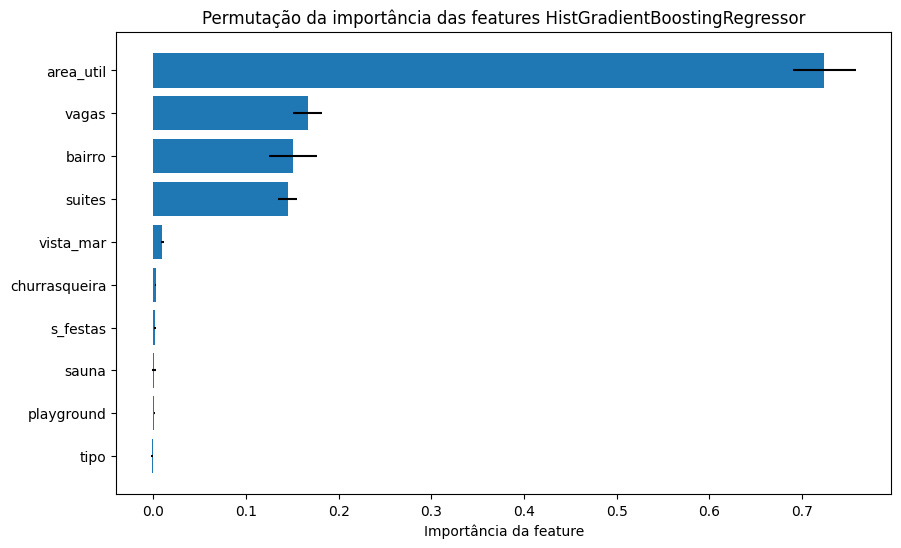

In [19]:
model = HistGradientBoostingRegressor()
model.fit(X_train, y_train)
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances = result.importances_mean
importances_std = result.importances_std
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], xerr=importances_std[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importância da feature')
plt.title('Permutação da importância das features HistGradientBoostingRegressor')
plt.show()

### 3.2 - Otimização de Hiperparâmetros

- Esta parte esta comentada pois a GridSearch demora bastante tempo. Portanto, para evitar uma execução muito longa, deixarei desativada. 
<br>Porém, os resultados são: ```{'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 20}```


In [20]:
gdb_clf = HistGradientBoostingRegressor()

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [20, 50, 100],
    'max_leaf_nodes': [31, 63, 127],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0]
}
grid_search = GridSearchCV(estimator=gdb_clf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_scaled, y_scaled)

best_params = grid_search.best_params_
print("Melhores parâmetros encontrados:", best_params)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Melhores parâmetros encontrados: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 20}


### 3.3 - Previsão final

In [21]:
model = HistGradientBoostingRegressor(l2_regularization=0, learning_rate=0.1, max_depth=7,
                                      max_iter=100, max_leaf_nodes=63, min_samples_leaf=20)
model.fit(X_scaled, y_scaled)
y_pred_scaled = model.predict(Kaggle_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

submission = pd.DataFrame({
    'Id': id_kaggle,
    'preco': y_pred
})
submission.to_csv('previsoes_preco.csv', index=False)